# 03 - Image Preprocessing

This notebook builds the preprocessing foundation for VisionInspect AI.

Before a model detects defects, images should be normalized and cleaned so the model receives consistent input.

## Learning Goals

In this notebook, we will implement:

- Resizing
- Grayscale conversion
- Noise removal
- Blur detection
- Contrast enhancement
- Brightness correction
- Rotation handling
- Thresholding
- Edge detection
- A reusable preprocessing pipeline

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample_images"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "preprocessing_practice"

SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Output directory: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\preprocessing_practice


## Helper Functions

These helpers make it easier to display multiple preprocessing outputs.

In [2]:
def show_image(image, title="Image", cmap=None, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(images, titles, cmaps=None, figsize=(14, 4)):
    if cmaps is None:
        cmaps = [None] * len(images)

    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]

    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def save_rgb(path, image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image_bgr)


def save_gray(path, gray_image):
    cv2.imwrite(str(path), gray_image)

## Create A Practice Product Image

Until the MVTec dataset is added, we use a synthetic product-like image. This lets us practice preprocessing safely.

Sample saved: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\sample_images\preprocessing_sample.png
Shape: (260, 360, 3)


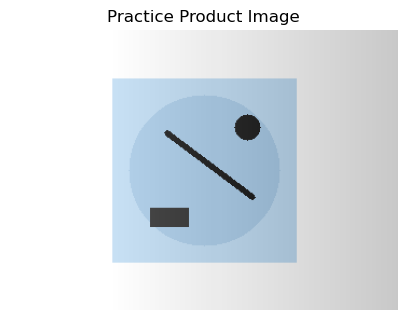

In [3]:
sample_path = SAMPLE_DIR / "preprocessing_sample.png"

image_rgb = np.full((260, 360, 3), 235, dtype=np.uint8)

# Product body
cv2.rectangle(image_rgb, (95, 45), (265, 215), (180, 205, 225), thickness=-1)
cv2.circle(image_rgb, (180, 130), 70, (160, 190, 215), thickness=-1)

# Artificial defect marks
cv2.line(image_rgb, (145, 95), (225, 155), (35, 35, 35), thickness=4)
cv2.circle(image_rgb, (220, 90), 12, (40, 40, 40), thickness=-1)
cv2.rectangle(image_rgb, (130, 165), (165, 182), (55, 55, 55), thickness=-1)

# Uneven lighting gradient
gradient = np.linspace(40, -35, image_rgb.shape[1]).astype(np.int16)
image_rgb = np.clip(image_rgb.astype(np.int16) + gradient[None, :, None], 0, 255).astype(np.uint8)

save_rgb(sample_path, image_rgb)

print("Sample saved:", sample_path)
print("Shape:", image_rgb.shape)
show_image(image_rgb, "Practice Product Image")

## Read Image And Convert Color Spaces

OpenCV reads images as BGR. For display, convert BGR to RGB.

For many preprocessing operations, convert BGR/RGB to grayscale.

RGB shape: (260, 360, 3)
Gray shape: (260, 360)


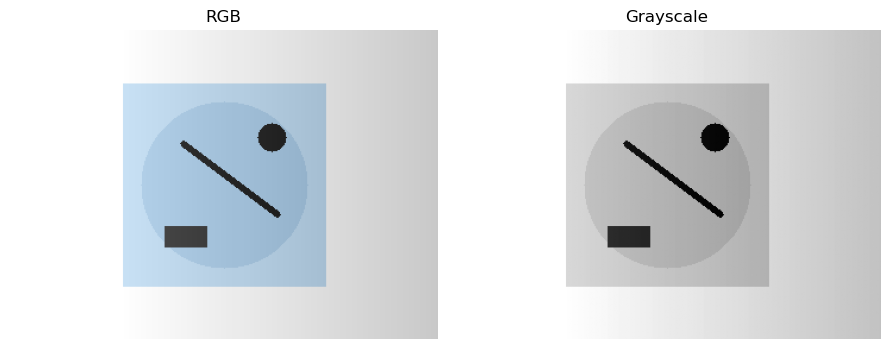

In [4]:
image_bgr = cv2.imread(str(sample_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("RGB shape:", image_rgb.shape)
print("Gray shape:", gray.shape)

show_images(
    [image_rgb, gray],
    ["RGB", "Grayscale"],
    [None, "gray"],
    figsize=(9, 4),
)

## Resizing

Deep learning models expect fixed image dimensions. Common sizes are `224 x 224` and `256 x 256`.

For our project, we will start with `256 x 256`.

Original: (260, 360, 3)
Resized: (256, 256, 3)


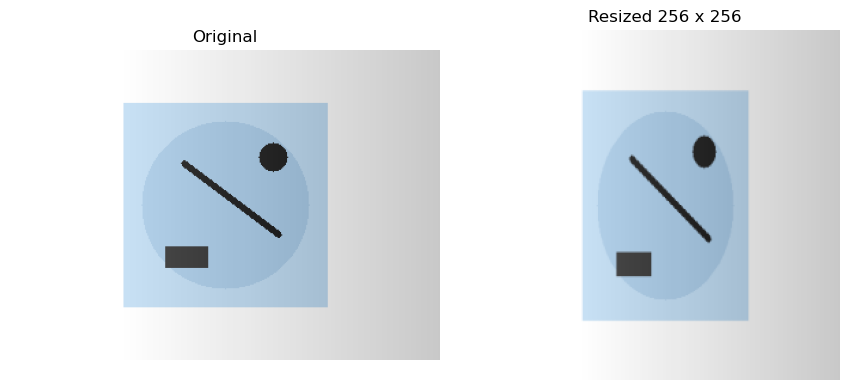

In [5]:
resized_rgb = cv2.resize(image_rgb, (256, 256), interpolation=cv2.INTER_AREA)

print("Original:", image_rgb.shape)
print("Resized:", resized_rgb.shape)

show_images(
    [image_rgb, resized_rgb],
    ["Original", "Resized 256 x 256"],
    figsize=(9, 4),
)

save_rgb(OUTPUT_DIR / "resized_256.png", resized_rgb)

## Noise Removal

Noise means random unwanted pixel variation. It can confuse edge detection and defect detection.

Common denoising methods:

- Gaussian blur
- Median blur
- Bilateral filter

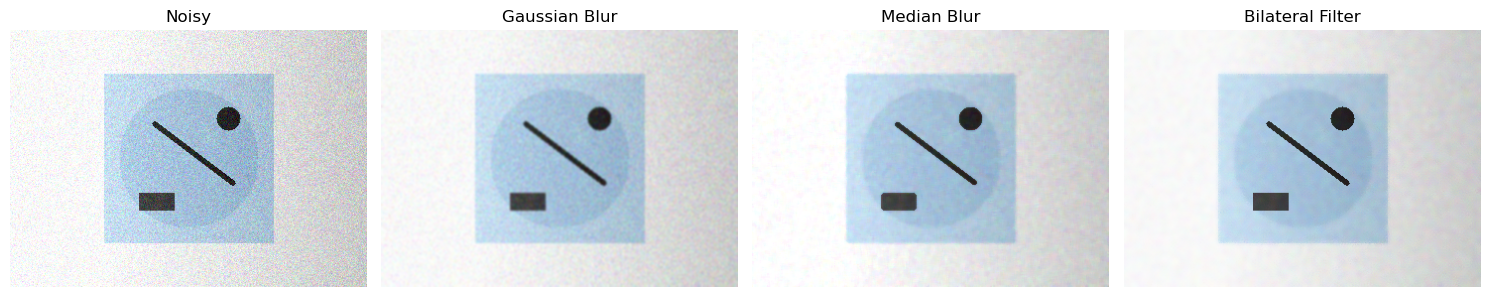

In [6]:
noise = np.random.normal(0, 18, image_rgb.shape).astype(np.int16)
noisy_rgb = np.clip(image_rgb.astype(np.int16) + noise, 0, 255).astype(np.uint8)

gaussian_rgb = cv2.GaussianBlur(noisy_rgb, (5, 5), 0)
median_rgb = cv2.medianBlur(noisy_rgb, 5)
bilateral_rgb = cv2.bilateralFilter(noisy_rgb, d=9, sigmaColor=75, sigmaSpace=75)

show_images(
    [noisy_rgb, gaussian_rgb, median_rgb, bilateral_rgb],
    ["Noisy", "Gaussian Blur", "Median Blur", "Bilateral Filter"],
    figsize=(15, 4),
)

save_rgb(OUTPUT_DIR / "noisy.png", noisy_rgb)
save_rgb(OUTPUT_DIR / "denoised_bilateral.png", bilateral_rgb)

## Blur Detection

A common blur score is the variance of the Laplacian.

- High variance: sharper image
- Low variance: blurrier image

This does not remove blur perfectly, but it helps flag poor-quality images.

Sharp image blur score: 404.83
Blurred image blur score: 1.25


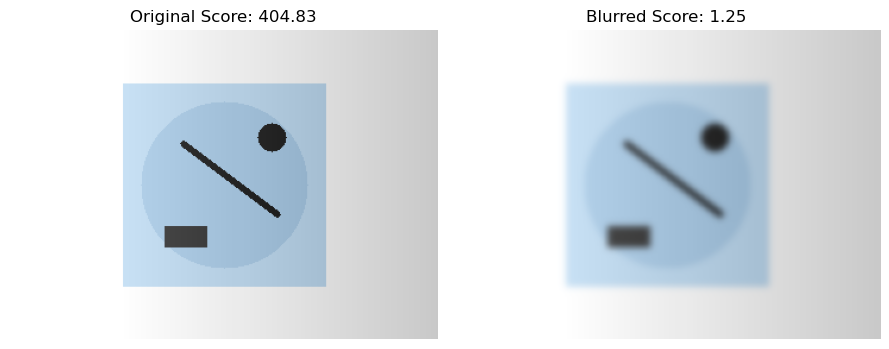

In [7]:
def blur_score(gray_image):
    return cv2.Laplacian(gray_image, cv2.CV_64F).var()


blurred_rgb = cv2.GaussianBlur(image_rgb, (17, 17), 0)
sharp_score = blur_score(gray)
blurred_score = blur_score(cv2.cvtColor(blurred_rgb, cv2.COLOR_RGB2GRAY))

print("Sharp image blur score:", round(sharp_score, 2))
print("Blurred image blur score:", round(blurred_score, 2))

show_images(
    [image_rgb, blurred_rgb],
    [f"Original Score: {sharp_score:.2f}", f"Blurred Score: {blurred_score:.2f}"],
    figsize=(9, 4),
)

save_rgb(OUTPUT_DIR / "blurred.png", blurred_rgb)

## Contrast Enhancement

Low contrast means the object and defect are not visually separated enough.

CLAHE is a strong practical method for local contrast enhancement.

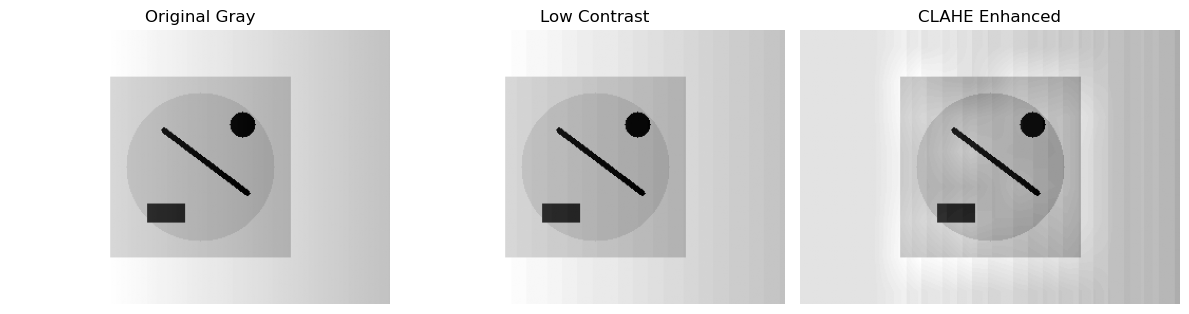

In [8]:
low_contrast_gray = cv2.normalize(gray, None, alpha=80, beta=150, norm_type=cv2.NORM_MINMAX)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_gray = clahe.apply(low_contrast_gray)

show_images(
    [gray, low_contrast_gray, enhanced_gray],
    ["Original Gray", "Low Contrast", "CLAHE Enhanced"],
    ["gray", "gray", "gray"],
    figsize=(12, 4),
)

save_gray(OUTPUT_DIR / "low_contrast.png", low_contrast_gray)
save_gray(OUTPUT_DIR / "contrast_enhanced.png", enhanced_gray)

## Brightness Correction

Brightness can be adjusted with:

`new_pixel = alpha * old_pixel + beta`

- `alpha`: contrast multiplier
- `beta`: brightness offset

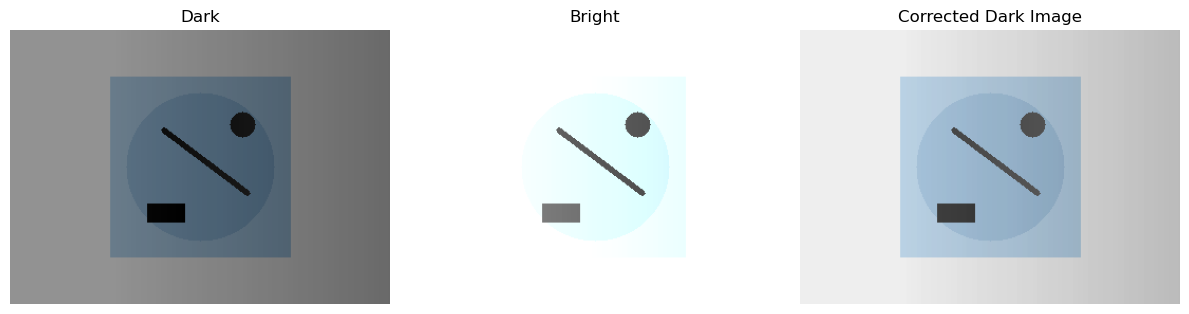

In [9]:
dark_rgb = cv2.convertScaleAbs(image_rgb, alpha=0.75, beta=-45)
bright_rgb = cv2.convertScaleAbs(image_rgb, alpha=1.15, beta=45)
corrected_rgb = cv2.convertScaleAbs(dark_rgb, alpha=1.25, beta=55)

show_images(
    [dark_rgb, bright_rgb, corrected_rgb],
    ["Dark", "Bright", "Corrected Dark Image"],
    figsize=(12, 4),
)

save_rgb(OUTPUT_DIR / "brightness_corrected.png", corrected_rgb)

## Uneven Lighting / Shadow Reduction

A useful classical technique is background estimation:

1. Estimate smooth background using heavy blur.
2. Subtract or normalize the image against the background.

This can help reduce shadows and uneven lighting.

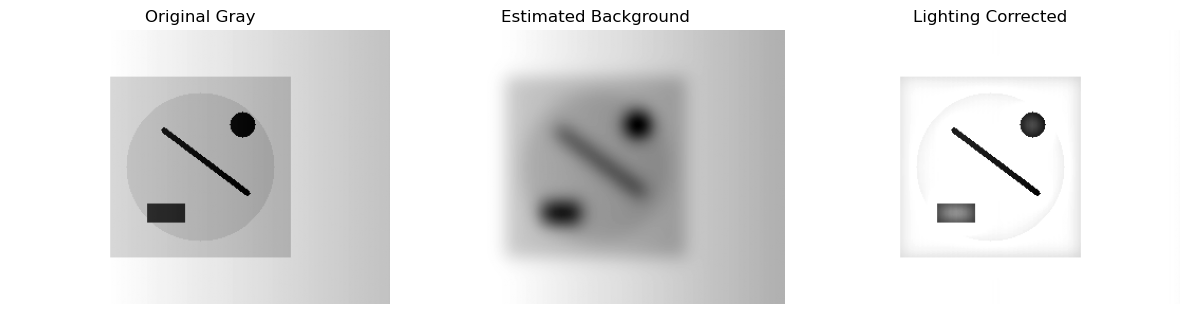

In [10]:
background = cv2.GaussianBlur(gray, (51, 51), 0)
lighting_corrected = cv2.divide(gray, background, scale=255)

show_images(
    [gray, background, lighting_corrected],
    ["Original Gray", "Estimated Background", "Lighting Corrected"],
    ["gray", "gray", "gray"],
    figsize=(12, 4),
)

save_gray(OUTPUT_DIR / "lighting_corrected.png", lighting_corrected)

## Rotation Handling

For production images, orientation may vary. Here we practice rotating and correcting an image.

Real automatic rotation correction can be harder and often depends on product shape or camera setup.

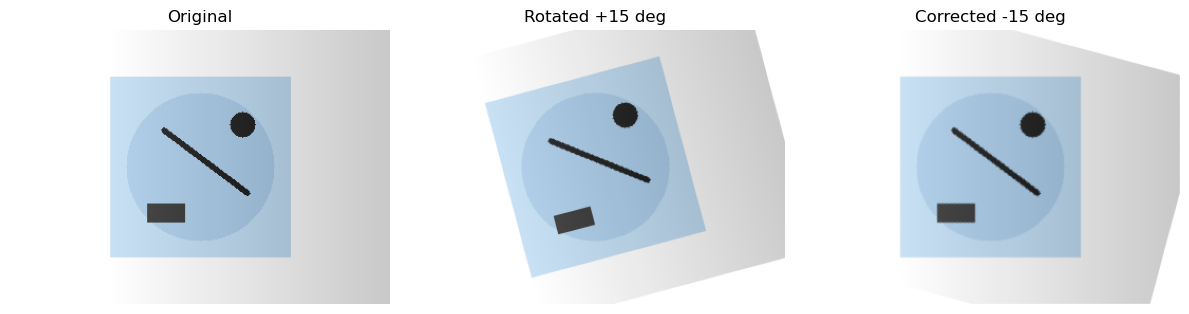

In [11]:
def rotate_image(image, angle):
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (width, height), borderValue=(255, 255, 255))
    return rotated


rotated_rgb = rotate_image(image_rgb, 15)
corrected_rotation_rgb = rotate_image(rotated_rgb, -15)

show_images(
    [image_rgb, rotated_rgb, corrected_rotation_rgb],
    ["Original", "Rotated +15 deg", "Corrected -15 deg"],
    figsize=(12, 4),
)

save_rgb(OUTPUT_DIR / "rotated.png", rotated_rgb)
save_rgb(OUTPUT_DIR / "rotation_corrected.png", corrected_rotation_rgb)

## Thresholding

Thresholding converts grayscale pixels into binary values.

It is useful for separating dark defects from a lighter background.

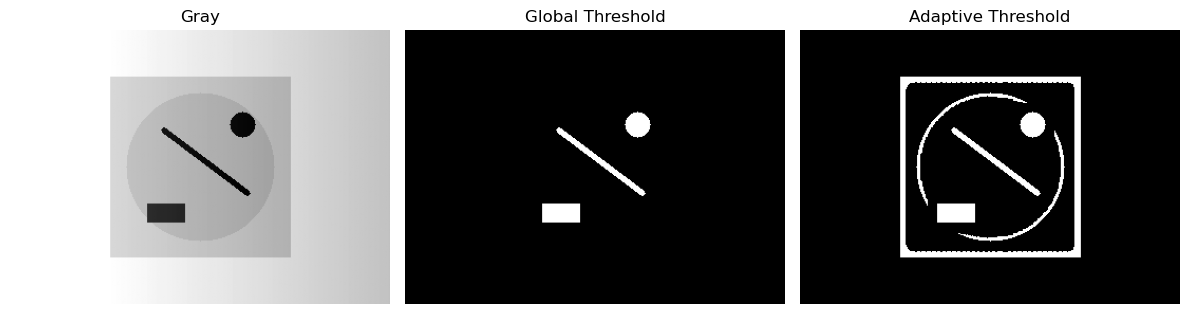

In [12]:
_, binary_threshold = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
adaptive_threshold = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5,
)

show_images(
    [gray, binary_threshold, adaptive_threshold],
    ["Gray", "Global Threshold", "Adaptive Threshold"],
    ["gray", "gray", "gray"],
    figsize=(12, 4),
)

save_gray(OUTPUT_DIR / "binary_threshold.png", binary_threshold)
save_gray(OUTPUT_DIR / "adaptive_threshold.png", adaptive_threshold)

## Edge Detection

Edges are sudden changes in intensity. Defects such as scratches and cracks often create strong edges.

Canny edge detection is a common classical method.

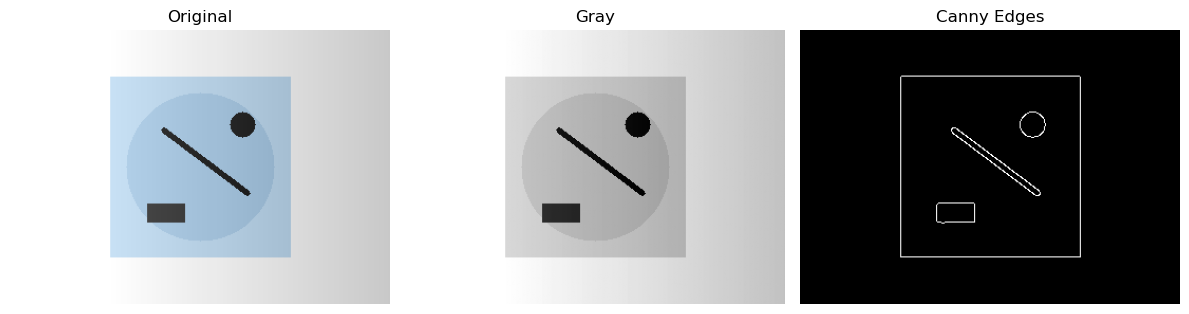

In [13]:
edges = cv2.Canny(gray, 80, 180)

show_images(
    [image_rgb, gray, edges],
    ["Original", "Gray", "Canny Edges"],
    [None, "gray", "gray"],
    figsize=(12, 4),
)

save_gray(OUTPUT_DIR / "edges.png", edges)

## Reusable Preprocessing Pipeline

Now we combine important steps into one function. Later, this type of code moves into `ml/preprocessing.py` and backend services.

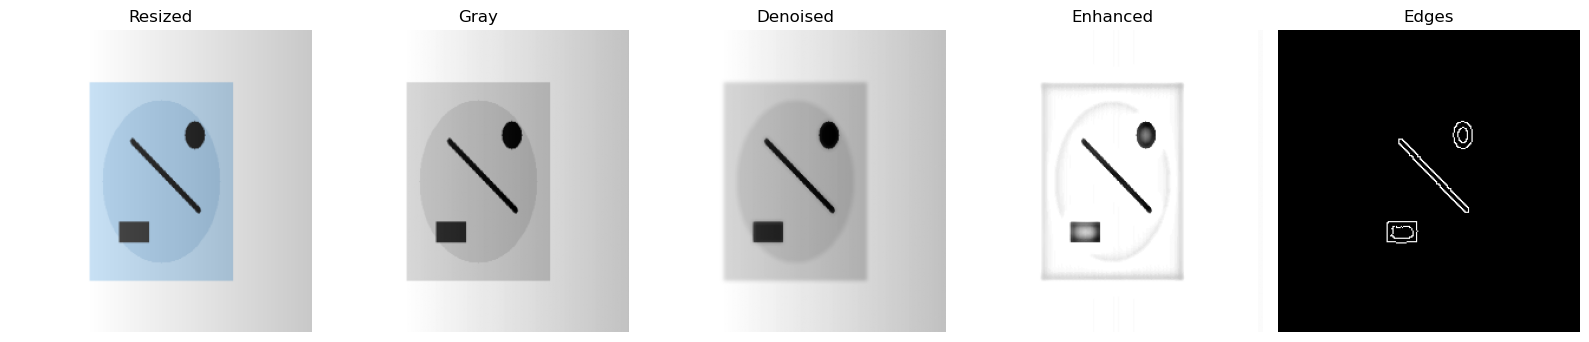

In [14]:
def preprocess_for_inspection(input_bgr, size=(256, 256)):
    resized = cv2.resize(input_bgr, size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    denoised = cv2.bilateralFilter(gray, d=7, sigmaColor=60, sigmaSpace=60)

    background = cv2.GaussianBlur(denoised, (31, 31), 0)
    lighting_corrected = cv2.divide(denoised, background, scale=255)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(lighting_corrected)

    edges = cv2.Canny(enhanced, 80, 180)

    return {
        "resized_bgr": resized,
        "gray": gray,
        "denoised": denoised,
        "lighting_corrected": lighting_corrected,
        "enhanced": enhanced,
        "edges": edges,
    }


pipeline_outputs = preprocess_for_inspection(image_bgr)

show_images(
    [
        cv2.cvtColor(pipeline_outputs["resized_bgr"], cv2.COLOR_BGR2RGB),
        pipeline_outputs["gray"],
        pipeline_outputs["denoised"],
        pipeline_outputs["enhanced"],
        pipeline_outputs["edges"],
    ],
    ["Resized", "Gray", "Denoised", "Enhanced", "Edges"],
    [None, "gray", "gray", "gray", "gray"],
    figsize=(16, 4),
)

## Save Pipeline Outputs

These files help us verify the preprocessing output visually.

In [15]:
cv2.imwrite(str(OUTPUT_DIR / "pipeline_resized.png"), pipeline_outputs["resized_bgr"])
cv2.imwrite(str(OUTPUT_DIR / "pipeline_gray.png"), pipeline_outputs["gray"])
cv2.imwrite(str(OUTPUT_DIR / "pipeline_denoised.png"), pipeline_outputs["denoised"])
cv2.imwrite(str(OUTPUT_DIR / "pipeline_lighting_corrected.png"), pipeline_outputs["lighting_corrected"])
cv2.imwrite(str(OUTPUT_DIR / "pipeline_enhanced.png"), pipeline_outputs["enhanced"])
cv2.imwrite(str(OUTPUT_DIR / "pipeline_edges.png"), pipeline_outputs["edges"])

print("Saved preprocessing outputs to:")
print(OUTPUT_DIR)

Saved preprocessing outputs to:
C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\preprocessing_practice


## Quality Checks

For an uploaded manufacturing image, we can calculate simple quality indicators before prediction.

In [16]:
def image_quality_report(input_bgr):
    gray = cv2.cvtColor(input_bgr, cv2.COLOR_BGR2GRAY)
    height, width = gray.shape
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    contrast = gray.std()

    return {
        "width": width,
        "height": height,
        "blur_score": round(float(blur), 2),
        "brightness_mean": round(float(brightness), 2),
        "contrast_std": round(float(contrast), 2),
    }


quality_report = image_quality_report(image_bgr)
quality_report

{'width': 360,
 'height': 260,
 'blur_score': 404.83,
 'brightness_mean': 218.89,
 'contrast_std': 34.56}

## Summary

You implemented the image preprocessing foundation:

- Resizing for fixed model input
- Grayscale conversion
- Noise removal
- Blur detection
- Contrast enhancement
- Brightness correction
- Shadow/lighting correction
- Rotation handling
- Thresholding
- Edge detection
- Reusable preprocessing pipeline

Next notebook: `04_mvtec_dataset_understanding.ipynb`.